In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("/content/CustomerChurn.csv")

In [37]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [41]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



SeniorCitizen is actually a categorical hence the 25%-50%-75% distribution is not propoer

75% customers have tenure less than 55 months

Average Monthly charges are USD 64.76 whereas 25% customers pay more than USD 89.85 per month

In [8]:
data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [9]:
data['Churn'].value_counts()/len(data) *100

,count
Churn,
No,73.463013
Yes,26.536987


## observation

**.** Data is highly imbalanced, ratio = 73:27

**.** So we analyse the data with other features while taking the target values separately to get some insights.

Text(0.5, 1.02, 'count of Target Variable per category')

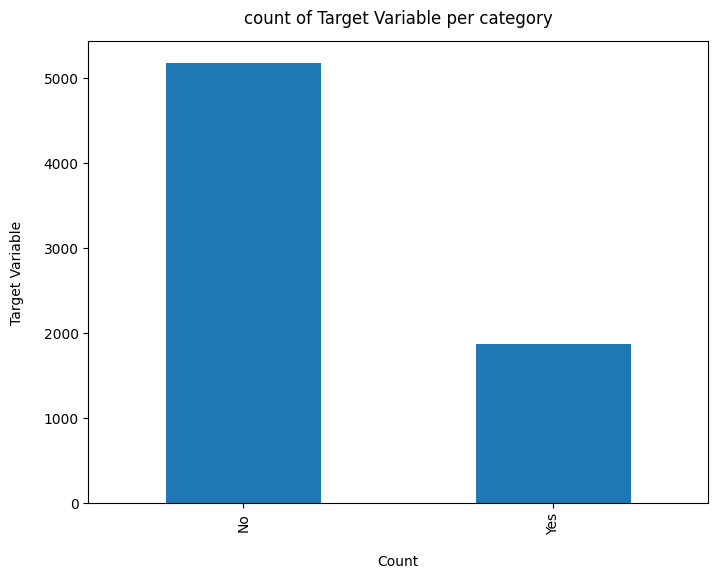

In [10]:
data['Churn'].value_counts().plot(kind='bar',figsize=(8,6))
plt.xlabel('Count',labelpad=14)
plt.ylabel("Target Variable",labelpad=14)
plt.title("count of Target Variable per category",y=1.02)

Observat

## Missing Data - Initial Intuition

. Here, we don't have any missing data.

## Data Cleaning

1. Create a copy of base data for manupulation & processing

In [11]:
df=data.copy()

**2.  Total Charges should be numeric amount. Let's convert it to numerical data type**

In [12]:
#df['TotalCharges'] = df['TotalCharges'].fillna(0).astype(int)  # handle NaN then convert
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce') # convert safely
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Observation

**3.** As we can see there are missing value in TotalCharge. let's check these records

In [13]:
df.loc[df['TotalCharges'].isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**4. Missing values Treatment**

.Since the % of these records compared to total dataset is very low ie 0.15%, it is safe to ignore them from further processing.

In [14]:

#Removing missing values
df.dropna(how='any',inplace=True)


5. Divide customers into bins based on tenure e.g. for tenure < 12 months: assign a tenure group if 1-12, for tenure between 1 to 2 Yrs, tenure group of 13-24; so on...

In [15]:
print(df['tenure'].max())

72


In [16]:
labels=["{0}-{1}".format(i,i+11)for i in  range (1,72,12)]
print(labels)

['1-12', '13-24', '25-36', '37-48', '49-60', '61-72']


In [17]:
# group the Tenure in bins of 12 months
labels=["{0} - {1}".format(i,i+11) for i in range(1,72,12)]
df['tenure_group']=pd.cut(df.tenure,range(1,80,12),right=False,labels=labels)

In [18]:
df['tenure_group'].value_counts()

,count
tenure_group,
1 - 12,2175
61 - 72,1407
13 - 24,1024
25 - 36,832
49 - 60,832
37 - 48,762


6.Remove columns not required for **analysis**

In [19]:
# we are droping tenure column because we now have tenure group column
df.drop(columns=['customerID','tenure'],axis=1,inplace=True)

In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


## Data Exploration

1. Plot distribution of individual predictors by churn

### Univariate Analysis

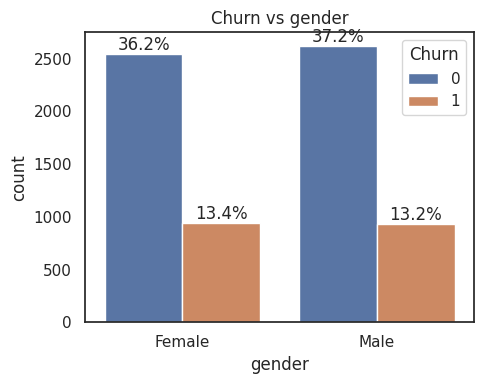

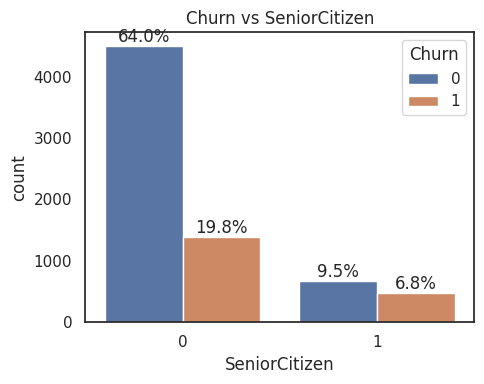

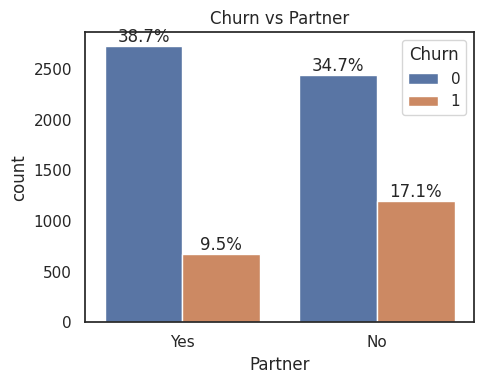

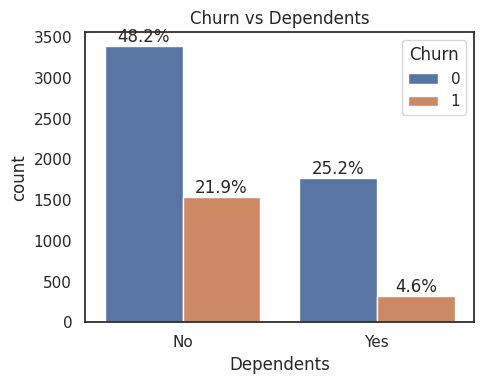

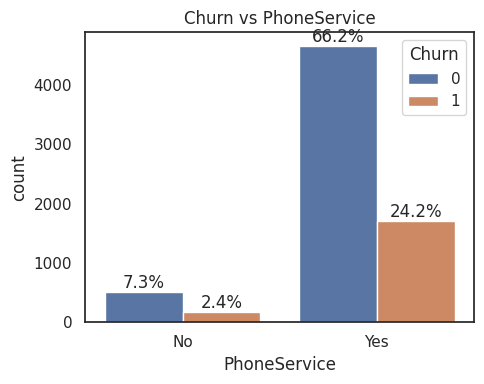

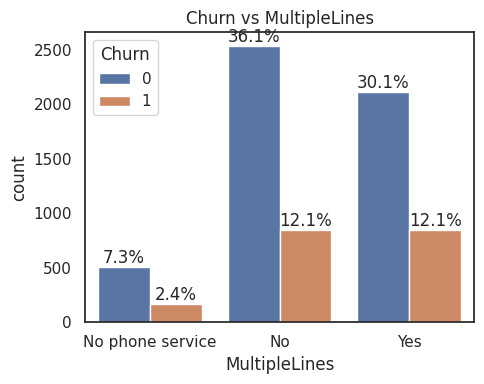

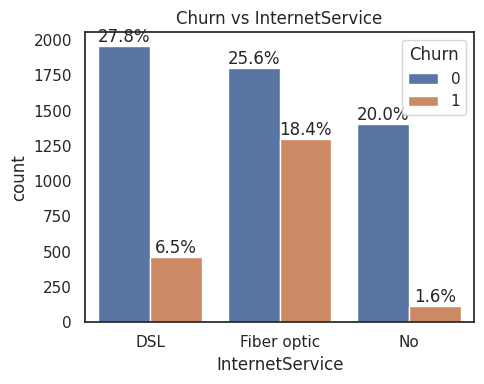

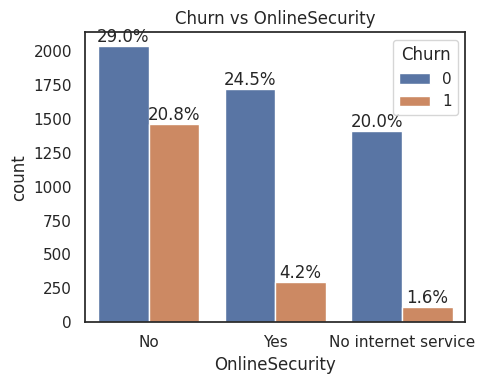

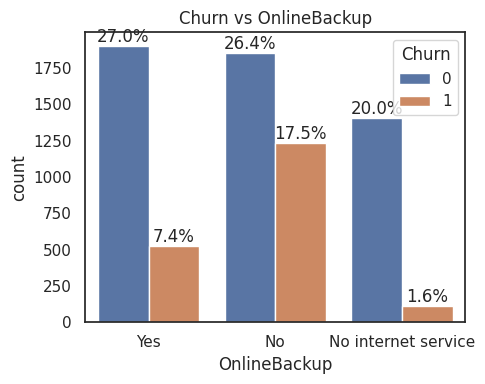

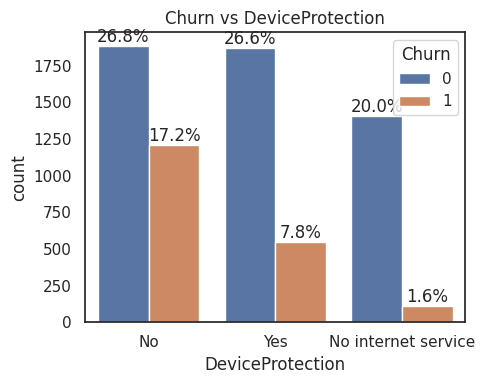

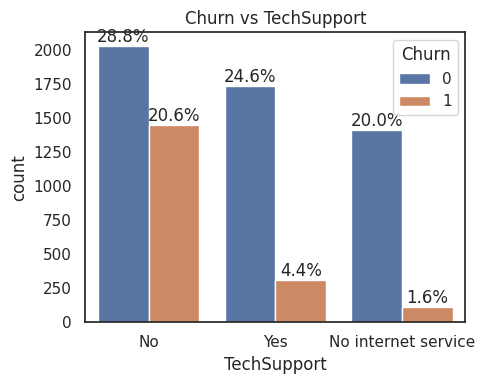

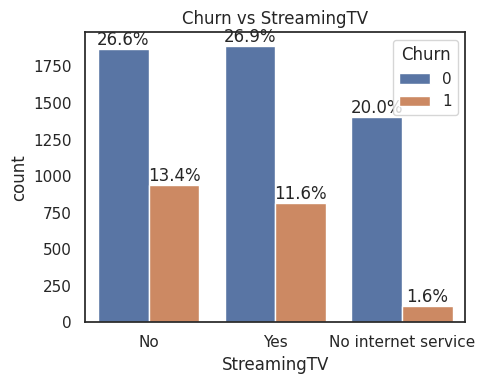

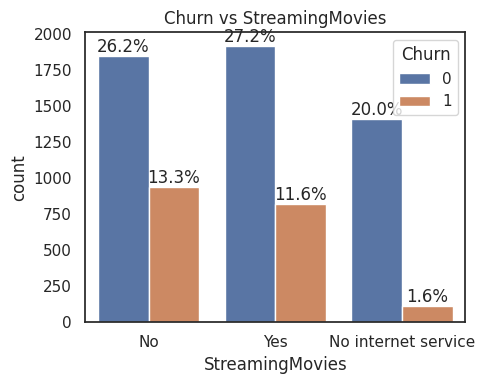

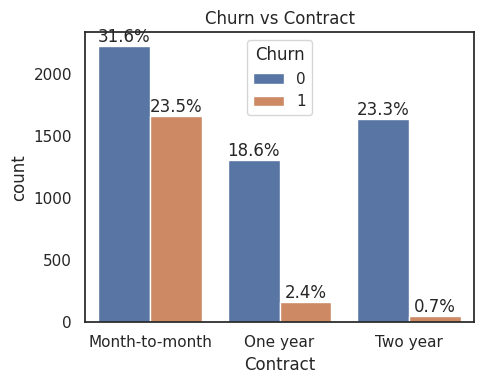

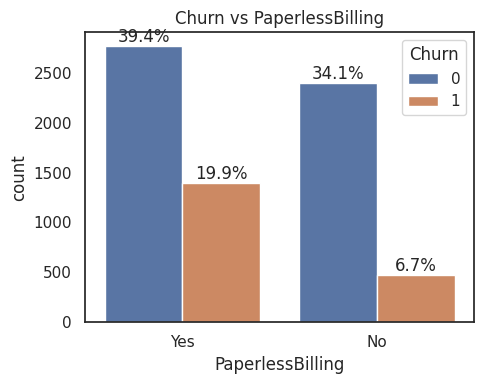

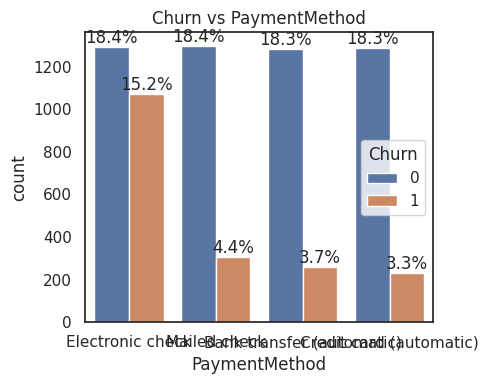

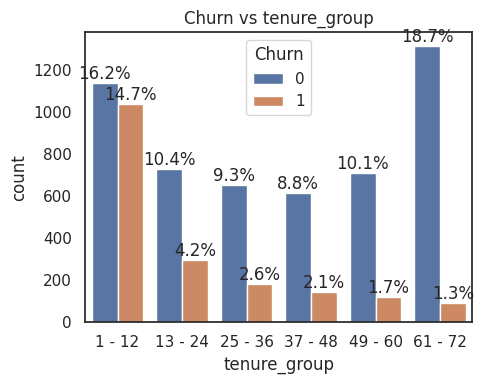

In [80]:
for i, predictor in enumerate(df.drop(columns=['Churn','TotalCharges','MonthlyCharges'])):

    plt.figure(figsize=(5,4))
    ax = sns.countplot(data=df, x=predictor, hue='Churn')

    # total rows
    total = len(df)

    # add percentage labels
    for container in ax.containers:
        labels = [
            f'{(bar.get_height()/total)*100:.1f}%'
            if bar.get_height() > 0 else ''
            for bar in container
        ]
        ax.bar_label(container, labels=labels)

    plt.title(f'Churn vs {predictor}')
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-2663290700.py:2: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  plt.figure(i,figsize=(5,4))


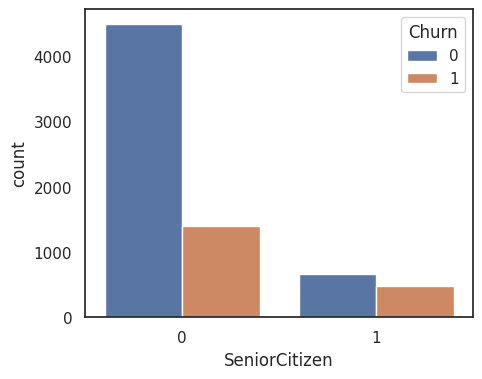

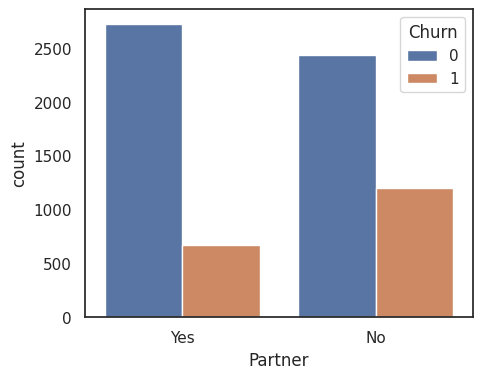

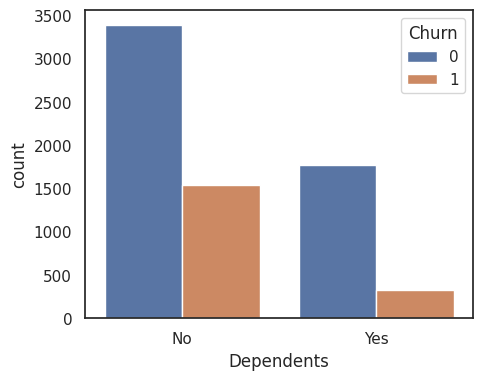

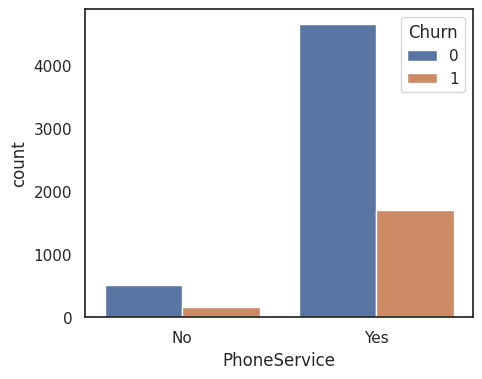

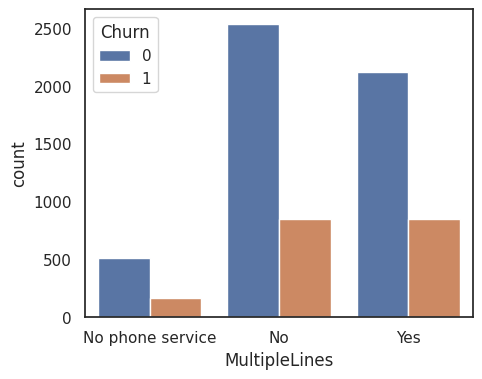

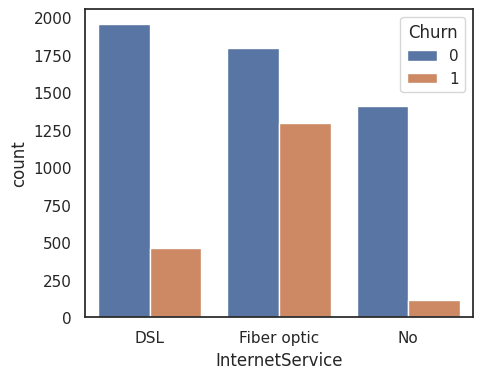

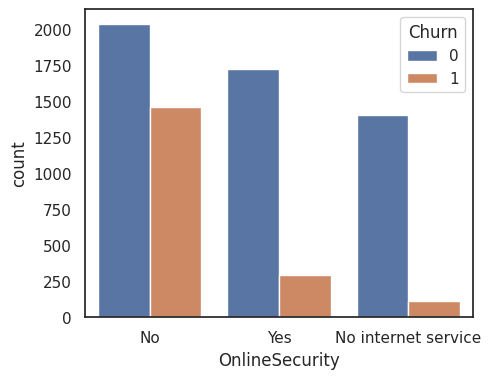

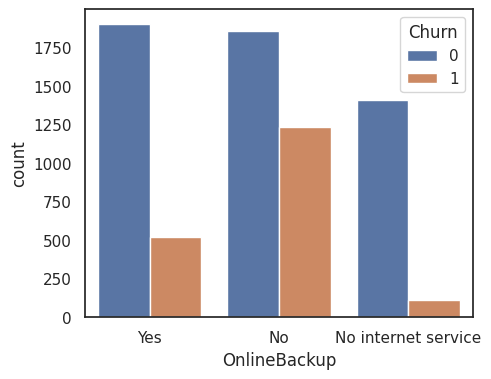

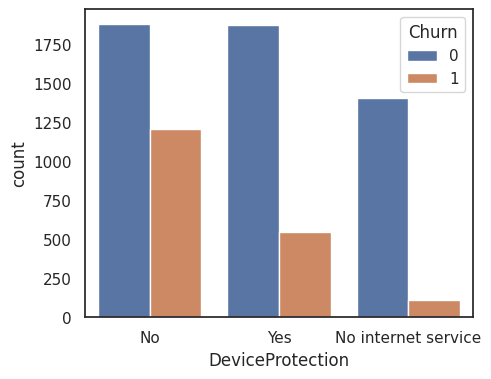

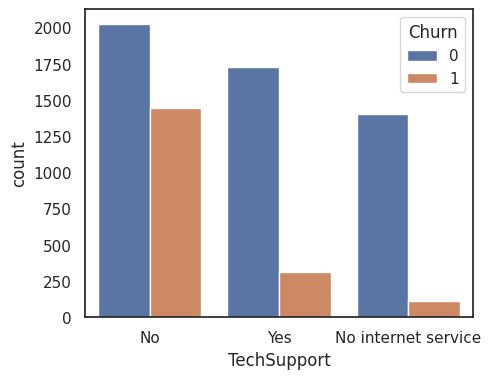

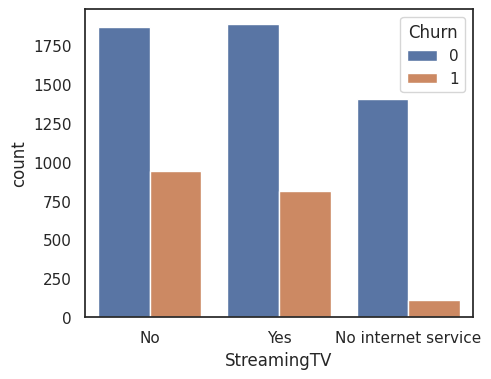

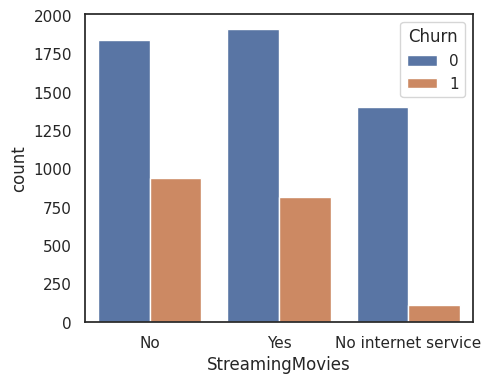

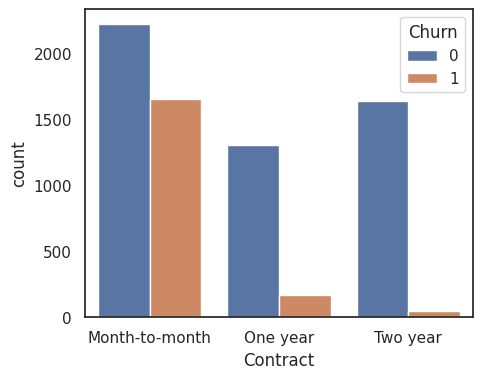

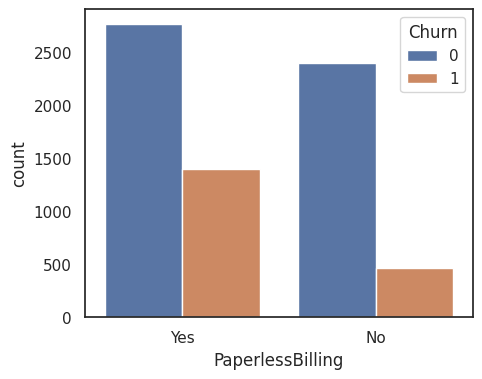

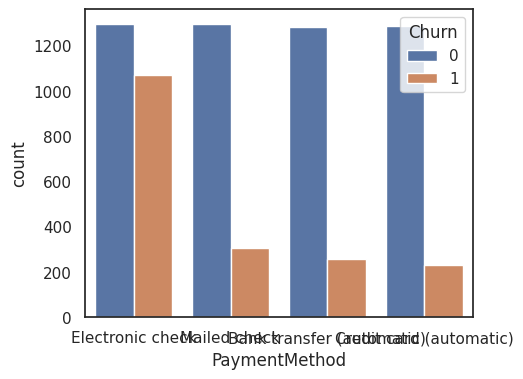

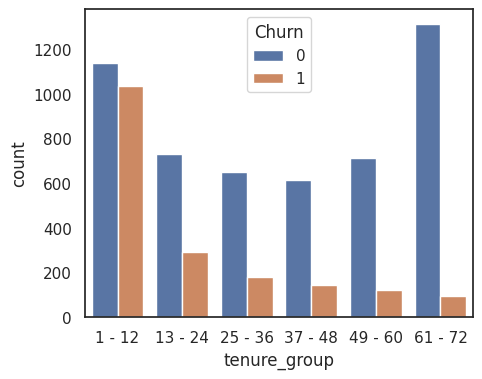

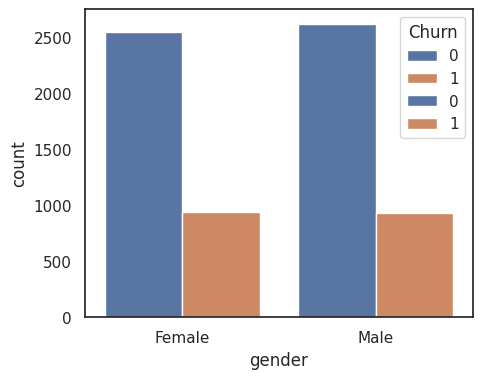

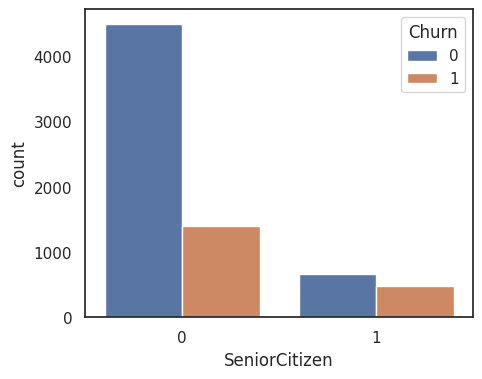

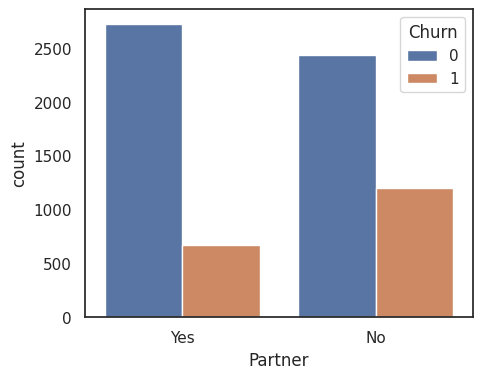

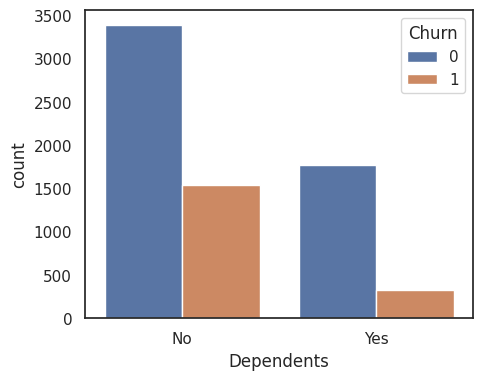

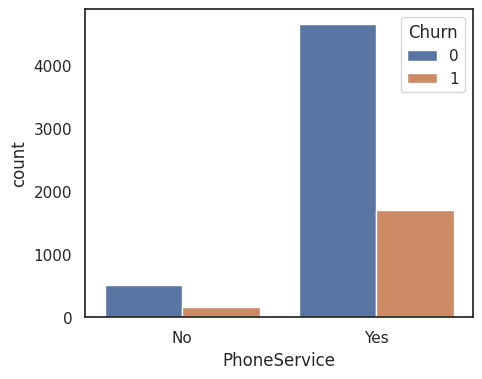

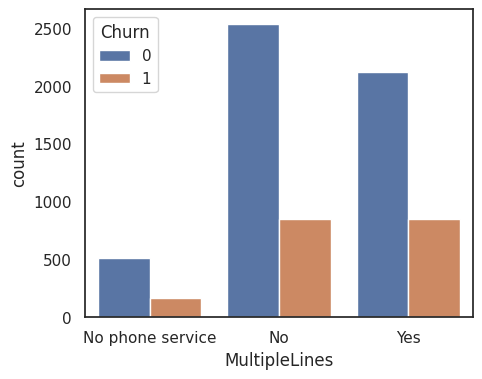

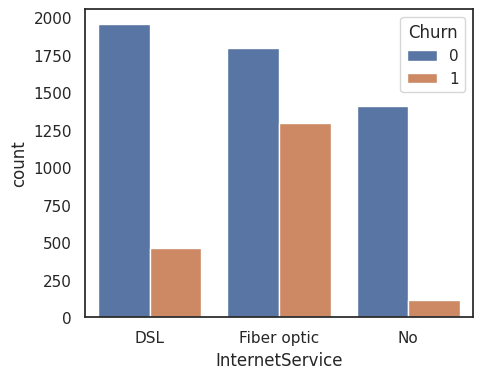

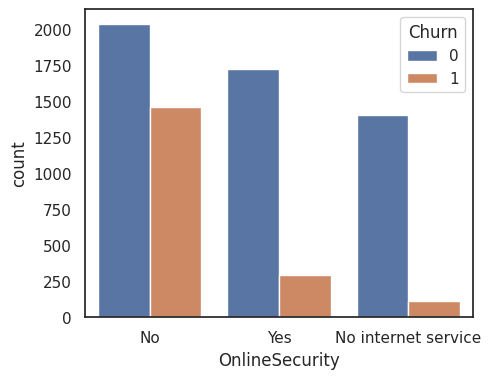

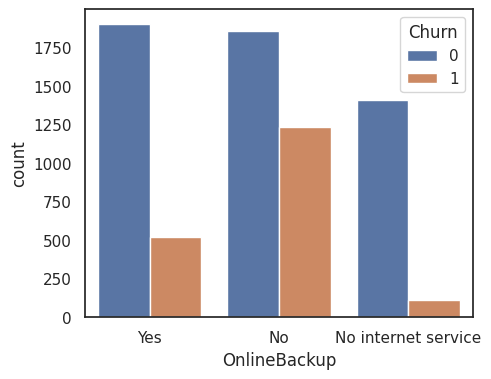

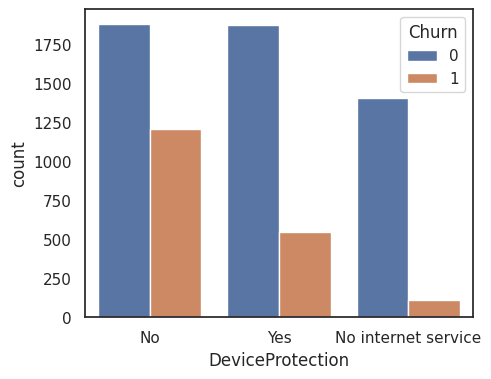

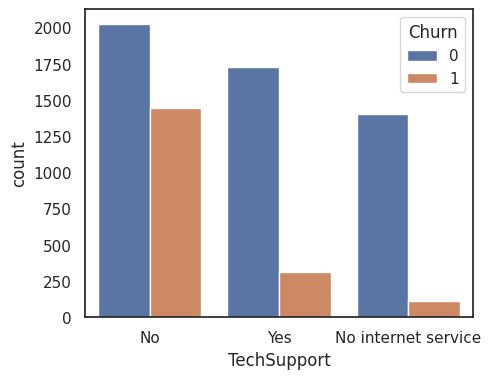

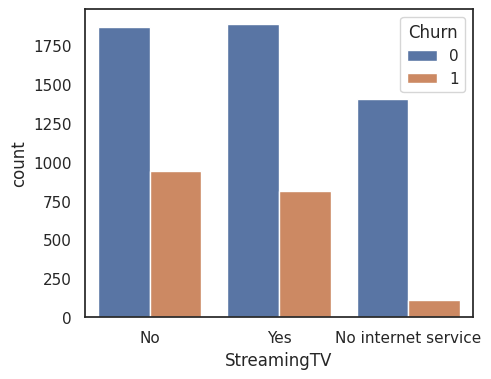

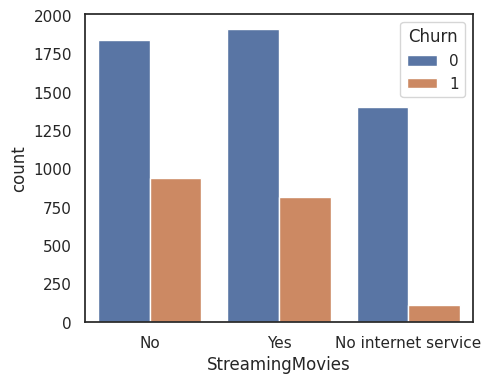

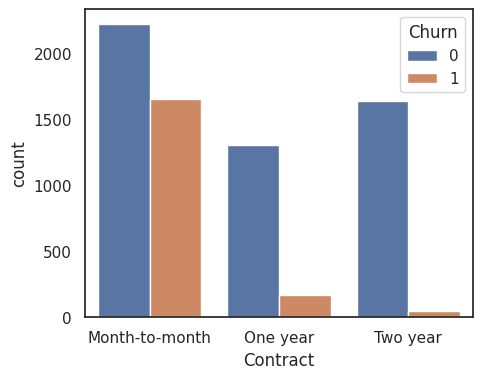

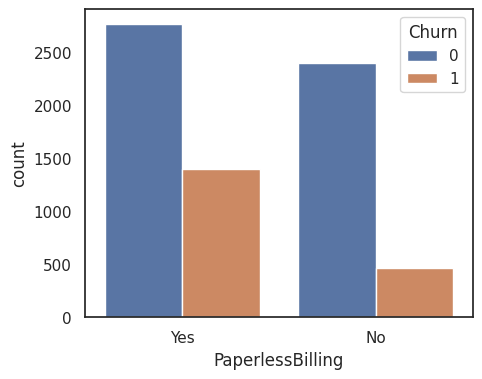

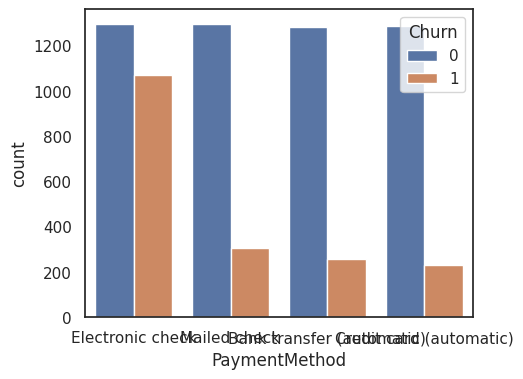

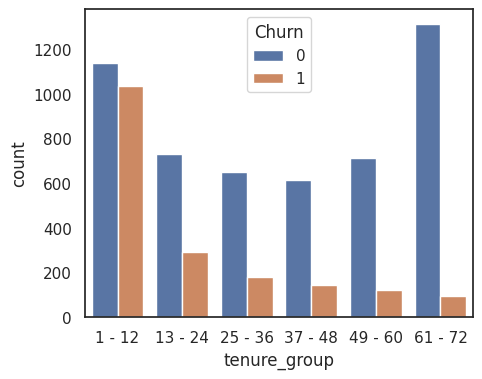

In [78]:
'''for i, predictor in enumerate(df.drop(columns=['Churn','TotalCharges','MonthlyCharges'])):
    plt.figure(i,figsize=(5,4))
    sns.countplot(data=df,x=predictor,hue='Churn')
    plt.show()'''

## Observation


.Gender does not significantly influence churn, as both male and female customers show similar churn distribution.

.Senior citizens have a relatively higher churn rate compared to non-senior customers.

Customers without partners are more likely to churn, while customers with partners show better retention.

.Customers with dependents tend to stay longer, indicating family-associated users are more stable.

.Phone service and multiple lines have only a minor impact on churn behavior.

.Fiber optic internet users exhibit the highest churn, whereas DSL and customers without internet service show lower churn rates.

.Customers without online security services have significantly higher churn, highlighting the importance of security features.

.Online backup and device protection services are associated with lower churn, suggesting value-added services improve retention.

.Lack of tech support strongly correlates with higher churn, making customer support a key retention factor.

.Streaming TV and streaming movie services show moderate influence and are not primary churn drivers.

.Customers using paperless billing demonstrate higher churn compared to traditional billing users.

.Electronic check payment method has the highest churn, while automatic payments (bank transfer and credit card) are linked to lower churn.

.Customer tenure is the strongest indicator of churn, with new customers (1–12 months) showing the highest churn and long-term customers showing strong retention.

2. convert the target variable ''Churn' in a binary numeric variable i.e yes=1,no=0

In [22]:
df['Churn']=np.where(df.Churn=='Yes',1,0)

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12



3. Convert all the categorical variables into dummy variables

In [24]:
df_dummies=pd.get_dummies(df)
df_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


**9. ** Relationship between Monthly Charges and Total Charges

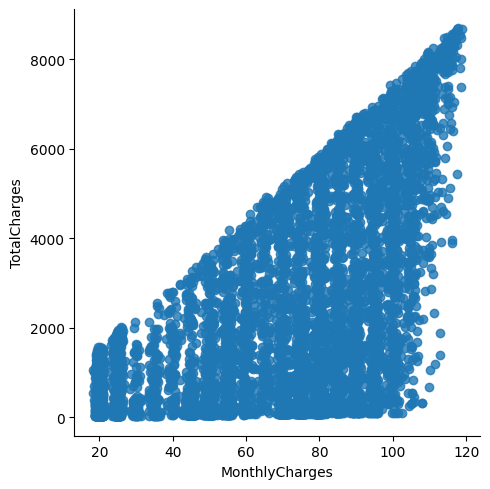

In [25]:
sns.lmplot(data=df_dummies,x='MonthlyCharges',y='TotalCharges',fit_reg=False)

In [26]:
print(df_dummies['TotalCharges'].dtype)
print(df_dummies['MonthlyCharges'].dtype)

float64
float64


In [27]:
df_dummies['MonthlyCharges'].corr(df_dummies['TotalCharges'])

np.float64(0.6510648032262027)

Total Charges increase as Monthly Charges increase - as expected.

**10. ** Churn by Monthly Charges and Total Charges

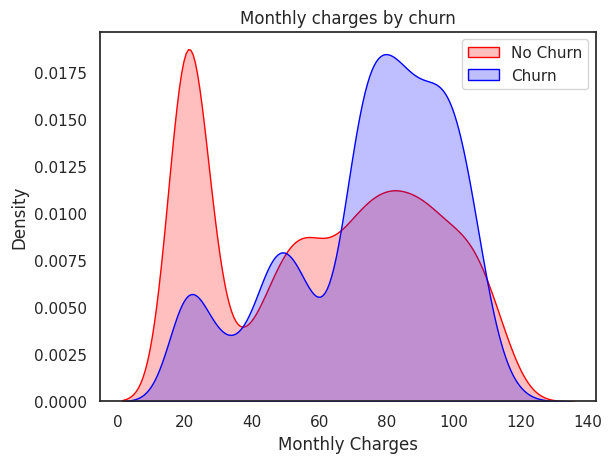

In [74]:
Mth=sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies['Churn']==0)],color='Red',fill=True)
sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies["Churn"] == 1) ],ax =Mth, color="Blue", fill= True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')
plt.show() # Added to display the plot

/tmp/ipython-input-335517749.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df_dummies.TotalCharges[(df_dummies["Churn"] == 0) ],
/tmp/ipython-input-335517749.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df_dummies.TotalCharges[(df_dummies["Churn"] == 1) ],


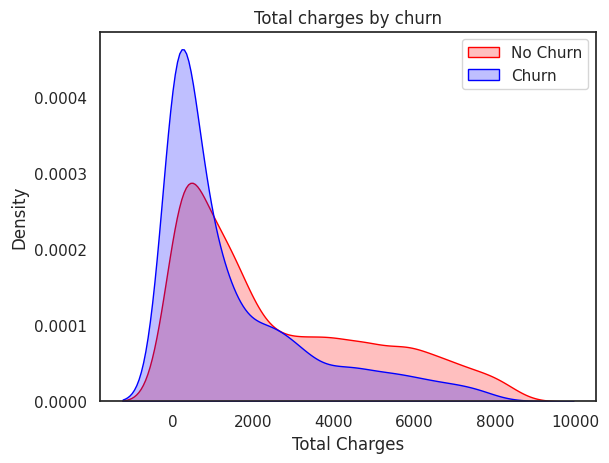

In [76]:
Tot = sns.kdeplot(df_dummies.TotalCharges[(df_dummies["Churn"] == 0) ],
                color="Red", shade = True)
Tot = sns.kdeplot(df_dummies.TotalCharges[(df_dummies["Churn"] == 1) ],
                ax =Tot, color="Blue", shade= True)
Tot.legend(["No Churn","Churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Charges')
Tot.set_title('Total charges by churn')
plt.show()

Insight: Churn is high when Monthly Charges ar **high** **bold text**

**Surprising insight ** as higher Churn at lower Total Charges


However if we combine the insights of 3 parameters i.e. Tenure, Monthly Charges & Total Charges then the picture is bit clear :- Higher Monthly Charge at lower tenure results into lower Total Charge. Hence, all these 3 factors viz Higher Monthly Charge, Lower tenure and Lower Total Charge are linkd to High Churn.


**11. Build a corelation of all predictors with 'Churn' **

<Axes: >

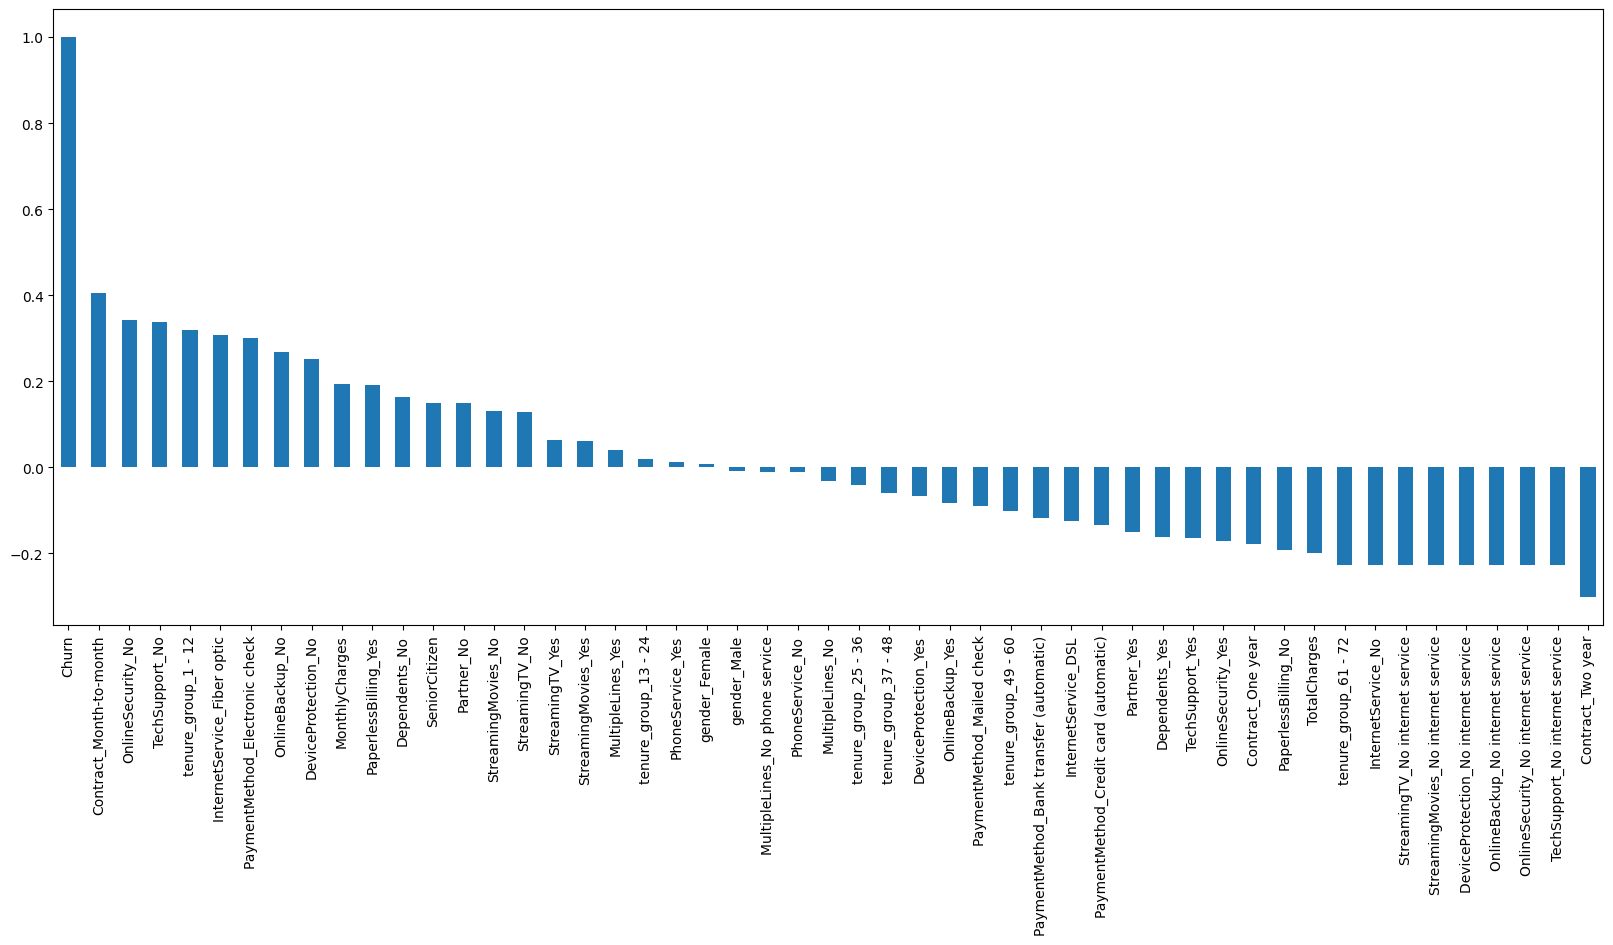

In [30]:
plt.figure(figsize=(20,8))
df_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

**Derived Insight: **

HIGH Churn seen in case of Month to month contracts, No online security, No Tech support, First year of subscription and Fibre Optics Internet

LOW Churn is seens in case of Long term contracts, Subscriptions without internet service and The customers engaged for 5+ years

Factors like Gender, Availability of PhoneService and # of multiple lines have alomost NO impact on Churn

This is also evident from the Heatmap below

<Axes: >

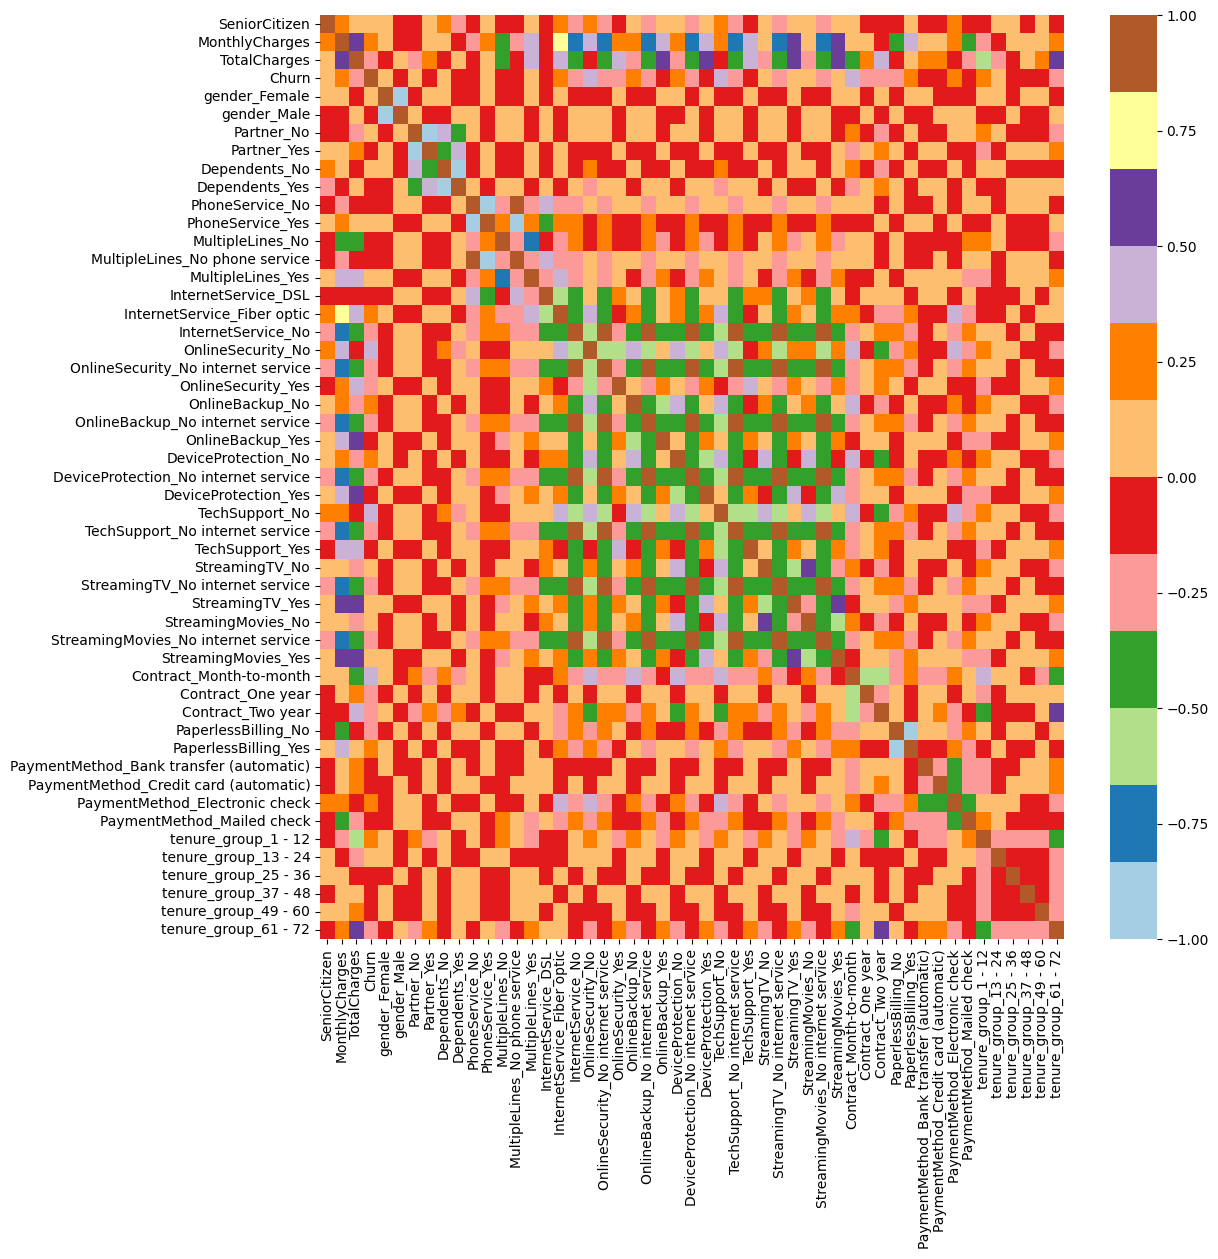

In [31]:
plt.figure(figsize=(12,12))
sns.heatmap(df_dummies.corr(), cmap="Paired")

## Bivariate Analysis

In [32]:
df_target0=df.loc[df["Churn"]==0]
df_target1=df.loc[df["Churn"]==1]

In [33]:

def uniplot(df,col,title,hue =None):

    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30


    temp = pd.Series(data = hue)
    fig, ax = plt.subplots()
    width = len(df[col].unique()) + 7 + 4*len(temp.unique())
    fig.set_size_inches(width , 8)
    plt.xticks(rotation=45)
    plt.yscale('log')
    plt.title(title)
    ax = sns.countplot(data = df, x= col, order=df[col].value_counts().index,hue = hue,palette='bright')

    plt.show()

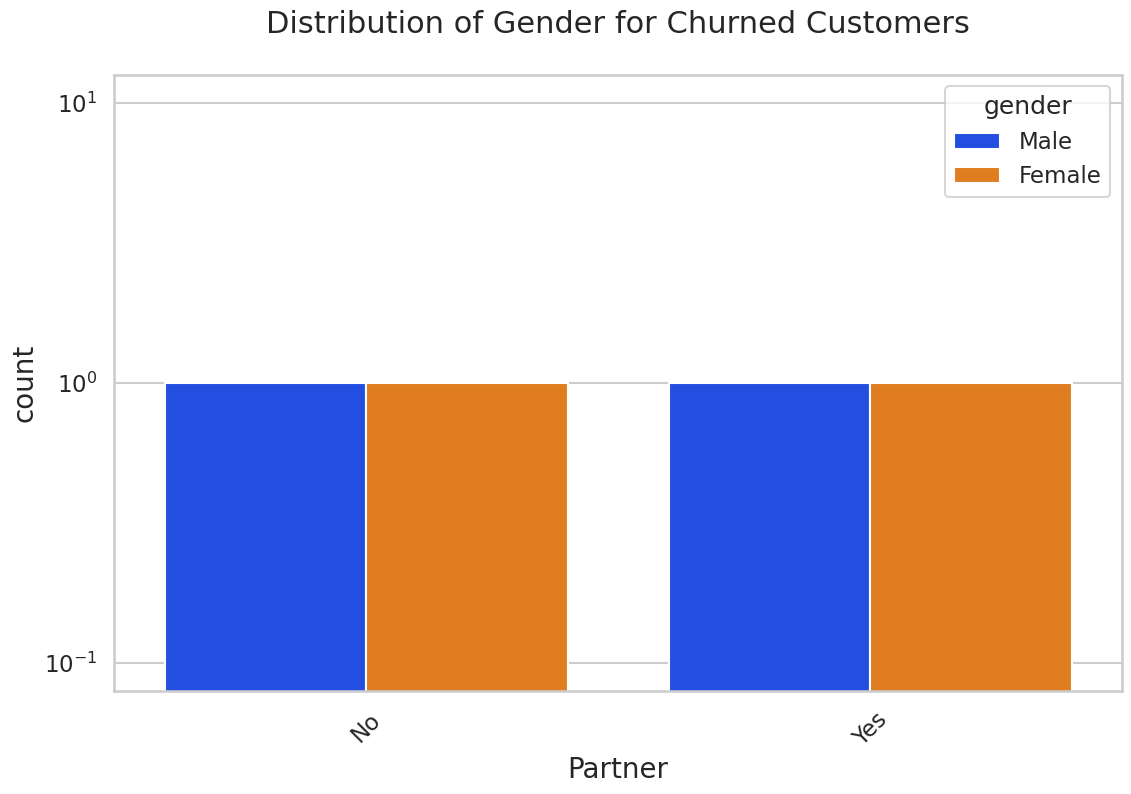

In [34]:
uniplot(df_target1,col='Partner',title='Distribution of Gender for Churned Customers',hue='gender')

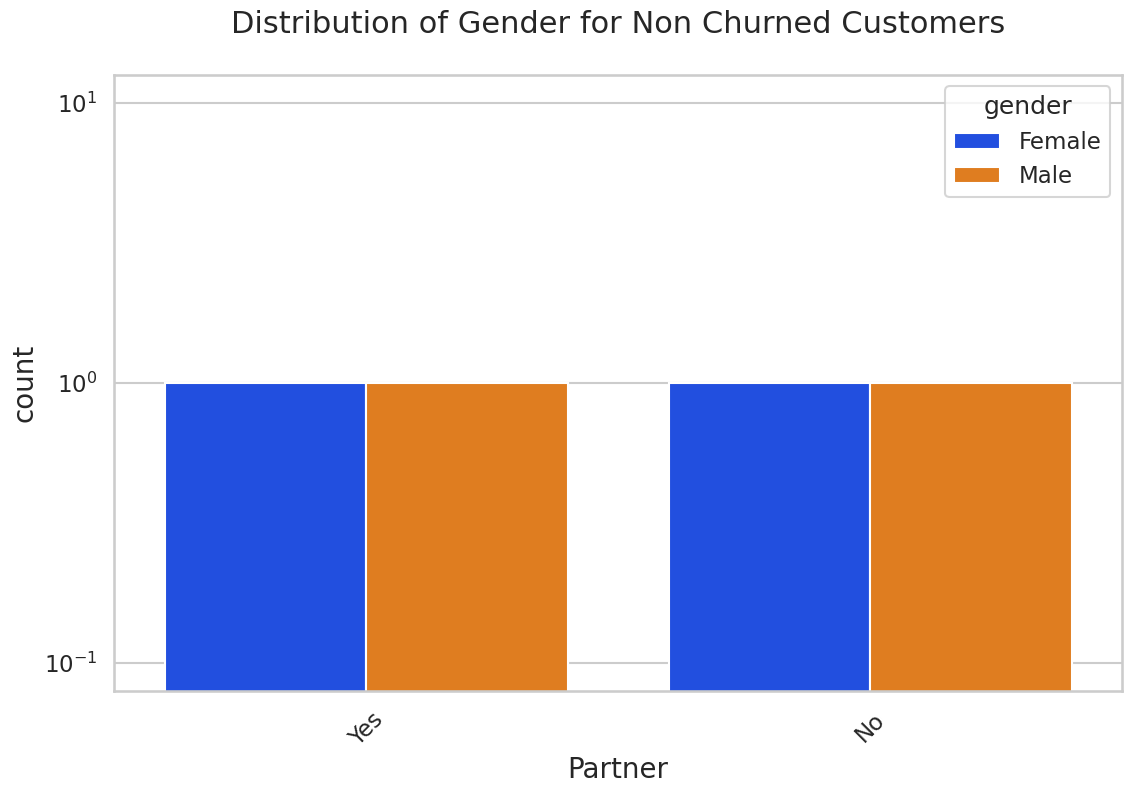

In [35]:
uniplot(df_target0,col='Partner',title='Distribution of Gender for Non Churned Customers',hue='gender')

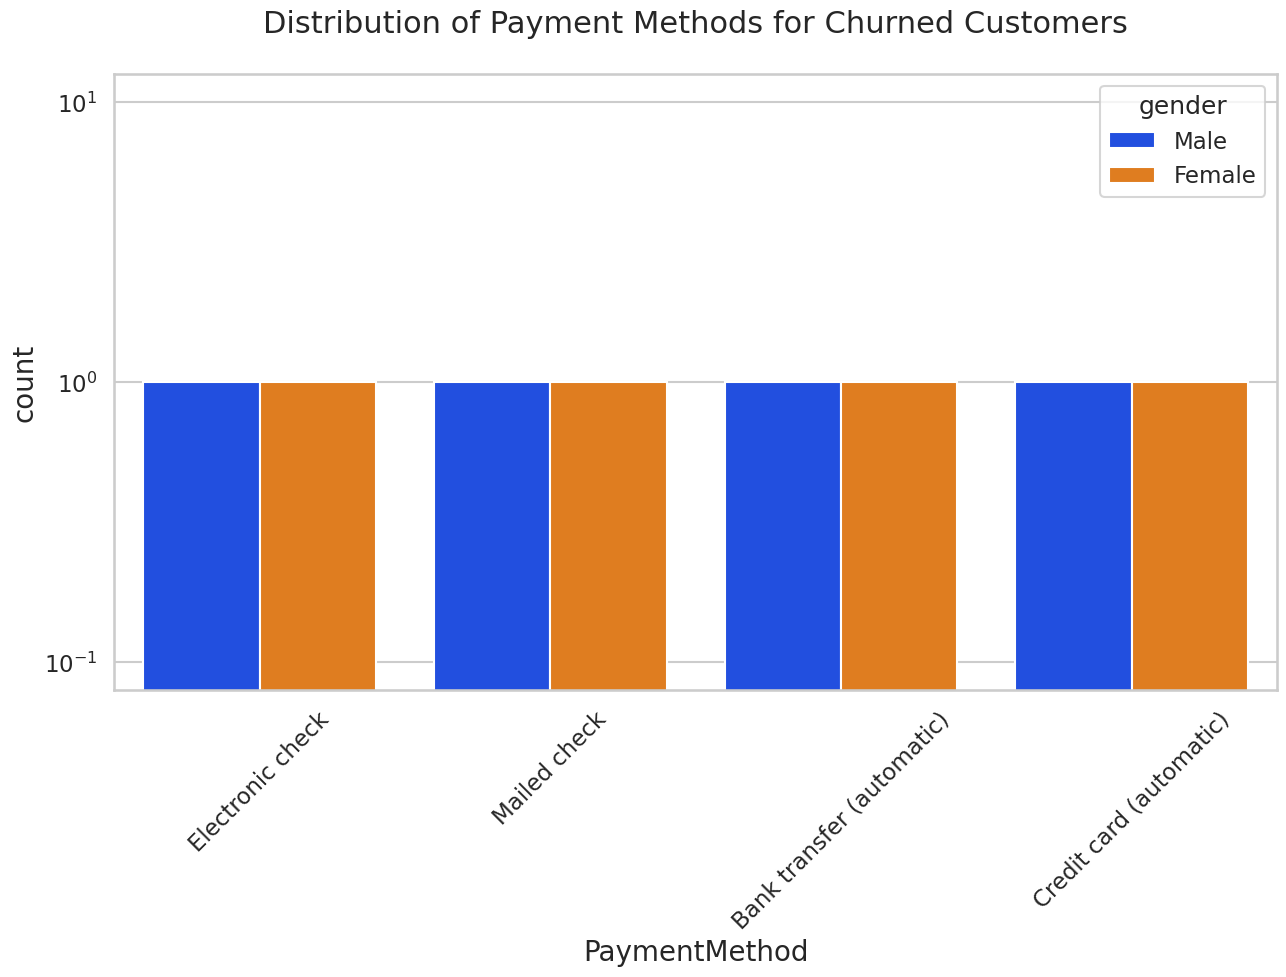

In [36]:
uniplot(df_target1,col='PaymentMethod',title='Distribution of Payment Methods for Churned Customers',hue='gender')

## **Customer Churn Analysis Report**

## 1. Introduction

Customer churn refers to customers discontinuing a company’s service over a given period. Understanding churn behavior helps organizations improve customer retention, optimize services, and increase long-term revenue.

This analysis explores customer demographics, service subscriptions, billing behavior, and pricing patterns to identify the major drivers of churn using Exploratory Data Analysis (EDA).

2. Dataset Overview

Total Customers: ≈ 7,043

Features analyzed: Demographics, services, billing, and tenure variables

Overall Churn Rate: ≈ 26–27%

Retained Customers: ≈ 73%

This indicates that roughly 1 in every 4 customers leaves the service.

3. Demographic Analysis
Gender

Male churn rate: ≈ 26%

Female churn rate: ≈ 27%

Insight: Gender has negligible impact (<1% difference) on churn behavior.

Senior Citizen

Non-senior churn: ≈ 23–24%

Senior citizen churn: ≈ 41–42%

Insight: Senior customers churn nearly 1.7 times more, suggesting possible usability or pricing concerns.

Partner and Dependents

Customers without partners: ≈ 32–33% churn

Customers with partners: ≈ 19–20% churn

Customers without dependents: ≈ 31–32% churn

Customers with dependents: ≈ 15–16% churn

Insight: Family-associated customers demonstrate significantly higher retention.

4. Service Usage Analysis
Phone Service & Multiple Lines

Minimal churn variation observed.

These services are weak churn predictors.

Internet Service (Major Driver)
Internet Type	Churn Rate
Fiber Optic	≈ 41–42%
DSL	≈ 19%
No Internet	≈ 7–8%

Insight: Fiber optic customers churn about 2× more than DSL users, indicating pricing or expectation mismatch.

5. Value-Added Services Impact
Service	With Service	Without Service
Online Security	~15% churn	~43% churn
Tech Support	~16% churn	~41% churn
Online Backup	~18–20% churn	~35–40% churn
Device Protection	~20% churn	~35% churn

Key Finding:
Customers subscribing to additional services show nearly 50% lower churn probability.

6. Billing and Payment Behavior
Paperless Billing

Paperless billing churn: ≈ 33–34%

Traditional billing churn: ≈ 16–17%

Insight: Flexible billing increases cancellation likelihood.

Payment Method
Payment Method	Churn Rate
Electronic Check	≈ 45%
Mailed Check	≈ 19%
Bank Transfer (Auto)	≈ 17%
Credit Card (Auto)	≈ 15%

Insight: Electronic check users churn nearly 3× more than automatic payment users.

7. Pricing Analysis
Monthly Charges

KDE distribution shows:

Higher monthly charges strongly associated with churn.

Customers paying premium prices leave more frequently.

Total Charges Insight

A surprising observation shows higher churn among customers with lower total charges.

Explanation:

Customers with short tenure accumulate lower total charges.

High monthly price combined with short subscription duration leads to early churn.

8. Customer Lifecycle (Tenure Analysis)
Tenure Period	Churn Behavior
1–12 months	≈45–50% churn (highest)
13–24 months	Moderate churn
25–48 months	Reduced churn
60+ months	<10% churn

Important Insight:
Customer churn is highest during the first year of subscription.

9. Combined Key Insight

Customers showing highest churn typically have:

High monthly charges

Low tenure

Low accumulated total charges

This indicates early dissatisfaction before long-term value creation.

10. Key Drivers of Churn
Strong Predictors

Low tenure (new customers)

Fiber optic internet service

Lack of tech support or online security

Electronic check payment method

High monthly charges

Weak Predictors

Gender

Phone service

Multiple lines

### 2. Dataset Overview

.Total Customers: ≈ 7,043

.Features analyzed: Demographics, services, billing, and tenure variables

.Overall Churn Rate: ≈ 26–27%

.Retained Customers: ≈ 73%

This indicates that roughly 1 in every 4 customers leaves the service.

### 3. Demographic Analysis
**Gender**

.Male churn rate: ≈ 26%

.Female churn rate: ≈ 27%

Insight: Gender has negligible impact (<1% difference) on churn behavior.

**Senior Citizen**

.Non-senior churn: ≈ 23–24%

.Senior citizen churn: ≈ 41–42%

Insight: Senior customers churn nearly 1.7 times more, suggesting possible usability or pricing concerns.

**Partner and Dependents**

.Customers without partners: ≈ 32–33% churn

.Customers with partners: ≈ 19–20% churn

.Customers without dependents: ≈ 31–32% churn

.Customers with dependents: ≈ 15–16% churn

Insight: Family-associated customers demonstrate significantly higher retention.

### 4. Service Usage Analysis
**Phone Service & Multiple Lines**

Minimal churn variation observed.

These services are weak churn predictors.

Internet Service (Major Driver)
Internet Type	Churn Rate

| Internet Type | Churn Rate   |
| ------------- | ------------ |
| Fiber Optic   | **≈ 41–42%** |
| DSL           | **≈ 19%**    |
| No Internet   | **≈ 7–8%**   |

Insight: Fiber optic customers churn about 2× more than DSL users, indicating pricing or expectation mismatch.

### 5. Value-Added Services Impact

| Service           | With Service  | Without Service |
| ----------------- | ------------- | --------------- |
| Online Security   | ~15% churn    | ~43% churn      |
| Tech Support      | ~16% churn    | ~41% churn      |
| Online Backup     | ~18–20% churn | ~35–40% churn   |
| Device Protection | ~20% churn    | ~35% churn      |

Key Finding:
Customers subscribing to additional services show nearly 50% lower churn probability.

### 6. Billing and Payment Behavior

Paperless Billing **bold text**

Paperless billing churn: ≈ 33–34%

Traditional billing churn: ≈ 16–17%

Insight: Flexible billing increases cancellation likelihood.

| Payment Method       | Churn Rate |
| -------------------- | ---------- |
| Electronic Check     | **≈ 45%**  |
| Mailed Check         | ≈ 19%      |
| Bank Transfer (Auto) | ≈ 17%      |
| Credit Card (Auto)   | ≈ 15%      |

Insight: Electronic check users churn nearly 3× more than automatic payment users.




### 7. Pricing Analysis
**Monthly Charges**

KDE distribution shows:

Higher monthly charges strongly associated with churn.

Customers paying premium prices leave more frequently.

**Total Charges Insight**

A surprising observation shows higher churn among customers with lower total charges.

Explanation:

Customers with short tenure accumulate lower total charges.

High monthly price combined with short subscription duration leads to early churn.

### 8. Customer Lifecycle (Tenure Analysis)
| Tenure Period | Churn Behavior              |
| ------------- | --------------------------- |
| 1–12 months   | **≈45–50% churn (highest)** |
| 13–24 months  | Moderate churn              |
| 25–48 months  | Reduced churn               |
| 60+ months    | **<10% churn**              |


Most Important Insight:
Customer churn is highest during the first year of subscription.

### 9. Combined Key Insight

Customers showing highest churn typically have:

High monthly charges

Low tenure

Low accumulated total charges

This indicates early dissatisfaction before long-term value creation.


### 10. Key Drivers of Churn
**Strong Predictors**

Low tenure (new customers)

Fiber optic internet service

Lack of tech support or online security

Electronic check payment method

High monthly charges

**Weak Predictors**

Gender

Phone service

Multiple lines

## **Business Recommendations**

Focus on early customer retention, as churn is highest (≈45–50%) within the first year. Introduce onboarding support and initial loyalty benefits.

Improve fiber optic service quality and pricing, since fiber users show the highest churn (≈41–42%).

Promote bundled services such as online security and tech support, which reduce churn by nearly 50%.

Encourage customers to adopt automatic payment methods, as electronic check users have the highest churn (~45%).

Provide targeted support for high-risk customers, including senior citizens and high monthly charge users.

Optimize pricing strategies to improve perceived value for customers with higher monthly charges.

## Conclusion

The customer churn analysis reveals that churn is primarily influenced by customer lifecycle stage, service experience, and billing behavior rather than demographic characteristics. Approximately 26–27% of customers churn, with the highest risk observed among new customers within the first year, particularly those with higher monthly charges and fiber optic services.

Customers subscribing to value-added services such as online security and technical support demonstrate significantly lower churn, highlighting the importance of service engagement. Additionally, customers using electronic check payment methods show the highest churn, while automatic payment users exhibit better retention.

Overall, the findings suggest that improving early customer experience, promoting bundled services, and encouraging automated payments can effectively reduce churn and enhance long-term customer retention.